In [1]:
from pathlib import Path


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"

print(f"Raíz del proyecto: {PROJECT_ROOT}")

Raíz del proyecto: c:\Users\adanm\Code\tesis


In [2]:
import sys

from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from experimento_aa import (
    prepare_aa_data,
    train_aa_and_reconstruct,
    calculate_aa_metrics,
)

from metricas import ari_metric

Using NumPy backend


In [3]:
DATASET_SELECCIONADO = "medianas_fase_50"
NORMALIZACION_SELECCIONADA = "minmax"
K_SELECCIONADO = 5
INICIALIZACION_AA = "pca_convex_hull_furthest_sum"

SEMILLAS_MODELO = (
    0,
    1,
    2,
    3,
    4,
)

N_ESTRELLAS_SUBMUESTRA = 5000
SEMILLA_MUESTREO = 42

In [4]:
from sklearn.model_selection import train_test_split


_, _, metadata_train_referencia, _ = prepare_aa_data(
    dataset="interpolacion_50",
    normalizacion=NORMALIZACION_SELECCIONADA,
)

subtipos_por_estrella = (
    metadata_train_referencia[
        ["star_id_base", "subtipo_rrlyrae"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

estrellas_submuestra, _ = train_test_split(
    subtipos_por_estrella,
    train_size=N_ESTRELLAS_SUBMUESTRA,
    random_state=SEMILLA_MUESTREO,
    stratify=subtipos_por_estrella["subtipo_rrlyrae"],
)

ids_submuestra = set(
    estrellas_submuestra["star_id_base"]
)

X_train, X_val, metadata_train, metadata_val = (
    prepare_aa_data(
        dataset=DATASET_SELECCIONADO,
        normalizacion=NORMALIZACION_SELECCIONADA,
    )
)

mascara_submuestra = (
    metadata_train["star_id_base"]
    .isin(ids_submuestra)
    .to_numpy()
)

X_train_submuestra = X_train[
    mascara_submuestra
]

metadata_train_submuestra = (
    metadata_train.loc[mascara_submuestra]
    .reset_index(drop=True)
)

if (
    metadata_train_submuestra["star_id_base"].nunique()
    != N_ESTRELLAS_SUBMUESTRA
):
    raise ValueError(
        "La submuestra no contiene las 5.000 estrellas esperadas."
    )

print(
    "Estrellas físicas seleccionadas: "
    f"{metadata_train_submuestra['star_id_base'].nunique():,}"
)
print(f"Curvas de entrenamiento: {X_train_submuestra.shape}")
print(f"Curvas de validación: {X_val.shape}")

Estrellas físicas seleccionadas: 5,000
Curvas de entrenamiento: (7313, 50)
Curvas de validación: (20576, 50)


In [5]:
resultados_semillas = []
grupos_val_por_semilla = {}
arquetipos_por_semilla = {}


for seed in SEMILLAS_MODELO:
    print(
        "\n"
        + "=" * 60
        + f"\nSemilla: {seed}"
        + "\n"
        + "=" * 60
    )

    resultado_modelo = train_aa_and_reconstruct(
        X_train=X_train_submuestra,
        X_val=X_val,
        k=K_SELECCIONADO,
        seed=seed,
        inicializacion=INICIALIZACION_AA,
    )

    metricas = calculate_aa_metrics(
        X_train=X_train_submuestra,
        X_val=X_val,
        metadata_val=metadata_val,
        resultado_modelo=resultado_modelo,
    )

    resultados_semillas.append(
        {
            "seed_modelo": seed,
            "tiempo_entrenamiento_segundos": (
                resultado_modelo["tiempo_entrenamiento"]
            ),
            "iteraciones_reales": (
                resultado_modelo["modelo"].n_iter_
            ),
            "convergio": (
                resultado_modelo["modelo"].n_iter_ < 300
            ),
            **metricas,
        }
    )

    grupos_val_por_semilla[seed] = (
        resultado_modelo["grupos_val"].copy()
    )

    arquetipos_por_semilla[seed] = (
        resultado_modelo["modelo"]
        .archetypes_
        .copy()
    )

    print(
        "Tiempo de entrenamiento: "
        f"{resultado_modelo['tiempo_entrenamiento']:.3f} s"
    )
    print(
        "Iteraciones: "
        f"{resultado_modelo['modelo'].n_iter_}"
    )
    print(f"MSE validación: {metricas['mse_val']:.6f}")
    print(f"Silhouette: {metricas['silhouette_val']:.6f}")
    print(
        "Davies-Bouldin: "
        f"{metricas['davies_bouldin_val']:.6f}"
    )
    print(f"Pureza: {metricas['purity_val']:.6f}")
    print(f"AMI: {metricas['ami_val']:.6f}")


df_resultados_semillas = (
    pd.DataFrame(resultados_semillas)
    .sort_values("seed_modelo")
    .reset_index(drop=True)
)

display(df_resultados_semillas)


Semilla: 0
Tiempo de entrenamiento: 18.622 s
Iteraciones: 82
MSE validación: 0.004276
Silhouette: 0.275879
Davies-Bouldin: 1.473842
Pureza: 0.913151
AMI: 0.427618

Semilla: 1
Tiempo de entrenamiento: 42.769 s
Iteraciones: 175
MSE validación: 0.003998
Silhouette: 0.211347
Davies-Bouldin: 1.624819
Pureza: 0.931085
AMI: 0.384801

Semilla: 2
Tiempo de entrenamiento: 18.285 s
Iteraciones: 82
MSE validación: 0.004276
Silhouette: 0.275879
Davies-Bouldin: 1.473842
Pureza: 0.913151
AMI: 0.427618

Semilla: 3
Tiempo de entrenamiento: 53.922 s
Iteraciones: 188
MSE validación: 0.003998
Silhouette: 0.211347
Davies-Bouldin: 1.624819
Pureza: 0.931085
AMI: 0.384801

Semilla: 4
Tiempo de entrenamiento: 44.059 s
Iteraciones: 194
MSE validación: 0.003998
Silhouette: 0.211347
Davies-Bouldin: 1.624819
Pureza: 0.931085
AMI: 0.384801


,seed_modelo,tiempo_entrenamiento_segundos,iteraciones_reales,convergio,mse_train,rss_train,mse_val,rss_val,purity_val,davies_bouldin_val,silhouette_val,ami_val
0,0,18.621619,82,True,0.004242,1551.063276,0.004276,4399.108510,0.913151,1.473842,0.275879,0.427618
1,1,42.769153,175,True,0.003956,1446.578408,0.003998,4113.524828,0.931085,1.624819,0.211347,0.384801
2,2,18.285115,82,True,0.004242,1551.063276,0.004276,4399.108510,0.913151,1.473842,0.275879,0.427618
3,3,53.922167,188,True,0.003956,1446.578430,0.003998,4113.524890,0.931085,1.624819,0.211347,0.384801
4,4,44.058802,194,True,0.003956,1446.578427,0.003998,4113.524882,0.931085,1.624819,0.211347,0.384801


In [6]:
comparaciones_ari = []


for seed_a, seed_b in combinations(
    SEMILLAS_MODELO,
    2,
):
    ari = ari_metric(
        grupos_val_por_semilla[seed_a],
        grupos_val_por_semilla[seed_b],
    )

    comparaciones_ari.append(
        {
            "seed_a": seed_a,
            "seed_b": seed_b,
            "ari": ari,
        }
    )


df_comparaciones_ari = pd.DataFrame(
    comparaciones_ari
)

resumen_ari = {
    "ari_mean": df_comparaciones_ari["ari"].mean(),
    "ari_std": df_comparaciones_ari["ari"].std(),
    "ari_min": df_comparaciones_ari["ari"].min(),
    "ari_max": df_comparaciones_ari["ari"].max(),
}

display(df_comparaciones_ari)

print("\nResumen ARI:")
for nombre, valor in resumen_ari.items():
    print(f"{nombre}: {valor:.6f}")

,seed_a,seed_b,ari
0,0,1,0.460893
1,0,2,1.000000
2,0,3,0.460893
3,0,4,0.460893
4,1,2,0.460893
5,1,3,1.000000
6,1,4,1.000000
7,2,3,0.460893
8,2,4,0.460893
9,3,4,1.000000



Resumen ARI:
ari_mean: 0.676536
ari_std: 0.278393
ari_min: 0.460893
ari_max: 1.000000


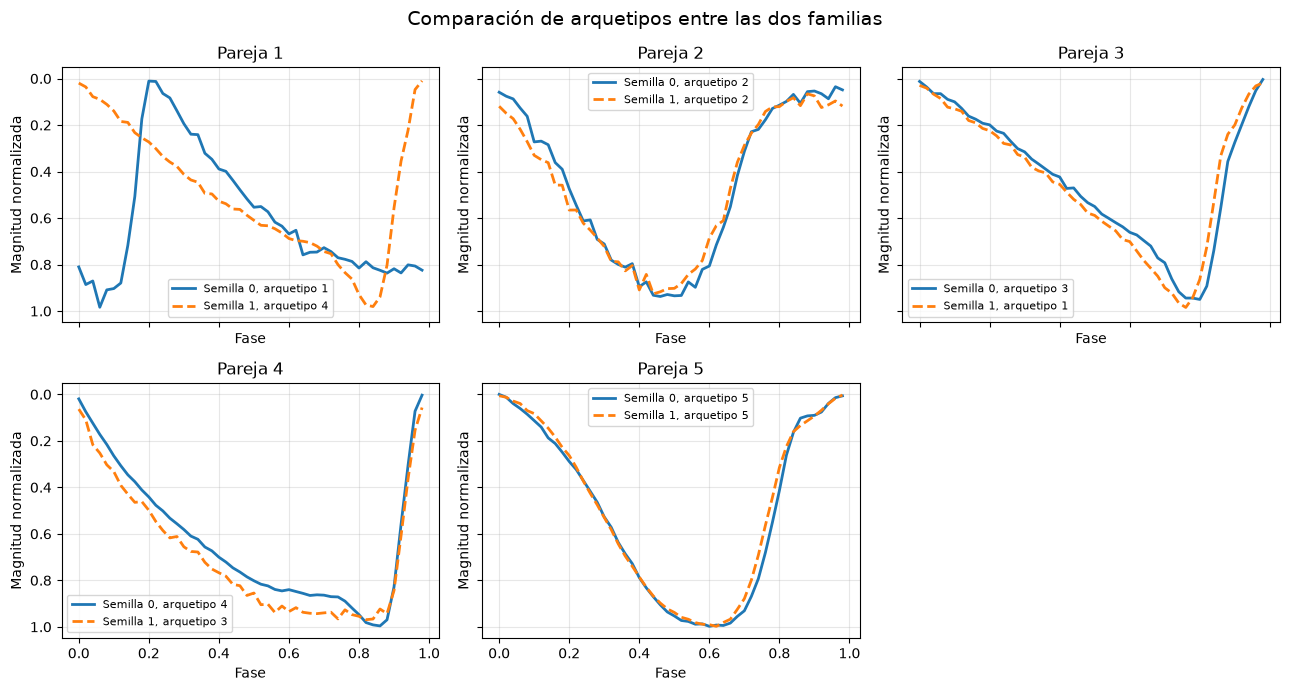

In [7]:
from scipy.optimize import linear_sum_assignment


arquetipos_seed_0 = arquetipos_por_semilla[0]
arquetipos_seed_1 = arquetipos_por_semilla[1]

matriz_distancias = np.linalg.norm(
    arquetipos_seed_0[:, np.newaxis, :]
    - arquetipos_seed_1[np.newaxis, :, :],
    axis=2,
)

indices_seed_0, indices_seed_1 = (
    linear_sum_assignment(matriz_distancias)
)

fases = np.linspace(
    0,
    1,
    arquetipos_seed_0.shape[1],
    endpoint=False,
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(13, 7),
    sharex=True,
    sharey=True,
)

for posicion, ax in enumerate(axes.flat):
    if posicion < K_SELECCIONADO:
        indice_0 = indices_seed_0[posicion]
        indice_1 = indices_seed_1[posicion]

        ax.plot(
            fases,
            arquetipos_seed_0[indice_0],
            label=f"Semilla 0, arquetipo {indice_0 + 1}",
            linewidth=2,
        )

        ax.plot(
            fases,
            arquetipos_seed_1[indice_1],
            label=f"Semilla 1, arquetipo {indice_1 + 1}",
            linewidth=2,
            linestyle="--",
        )

        ax.set_title(f"Pareja {posicion + 1}")
        ax.set_xlabel("Fase")
        ax.set_ylabel("Magnitud normalizada")
        ax.invert_yaxis()
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    else:
        ax.axis("off")

fig.suptitle(
    "Comparación de arquetipos entre las dos familias",
    fontsize=14,
)

plt.tight_layout()
plt.show()

In [8]:
CARPETA_SELECCION_AA = (
    PROJECT_ROOT
    / "resultados"
    / "seleccion_parametros_aa"
)

CARPETA_SELECCION_AA.mkdir(
    parents=True,
    exist_ok=True,
)

ruta_semillas_csv = (
    CARPETA_SELECCION_AA
    / "estabilidad_semillas_aa.csv"
)

ruta_semillas_parquet = (
    CARPETA_SELECCION_AA
    / "estabilidad_semillas_aa.parquet"
)

ruta_ari_csv = (
    CARPETA_SELECCION_AA
    / "estabilidad_ari_aa.csv"
)

ruta_ari_parquet = (
    CARPETA_SELECCION_AA
    / "estabilidad_ari_aa.parquet"
)

df_resultados_semillas.to_csv(
    ruta_semillas_csv,
    index=False,
)

df_resultados_semillas.to_parquet(
    ruta_semillas_parquet,
    index=False,
)

df_comparaciones_ari.to_csv(
    ruta_ari_csv,
    index=False,
)

df_comparaciones_ari.to_parquet(
    ruta_ari_parquet,
    index=False,
)

print(f"Resultados por semilla: {ruta_semillas_csv}")
print(f"Comparaciones ARI: {ruta_ari_csv}")

Resultados por semilla: c:\Users\adanm\Code\tesis\resultados\seleccion_parametros_aa\estabilidad_semillas_aa.csv
Comparaciones ARI: c:\Users\adanm\Code\tesis\resultados\seleccion_parametros_aa\estabilidad_ari_aa.csv


In [9]:
ruta_registro = (
    PROJECT_ROOT
    / "resultados"
    / "registro_experimentos.parquet"
)

registro = pd.read_parquet(
    ruta_registro
)

mascara_aa_final = (
    registro["modelo"].eq("archetypal_analysis")
    & registro["dataset"].eq(DATASET_SELECCIONADO)
    & registro["normalizacion"].eq(
        NORMALIZACION_SELECCIONADA
    )
    & registro["K"].eq(K_SELECCIONADO)
    & registro["inicializacion"].eq(
        INICIALIZACION_AA
    )
    & registro["seed_modelo"].isin(
        SEMILLAS_MODELO
    )
)

df_aa_final = (
    registro.loc[mascara_aa_final]
    .sort_values("seed_modelo")
    .reset_index(drop=True)
)

if len(df_aa_final) != 5:
    raise ValueError(
        "No se encontraron las cinco "
        "ejecuciones finales de AA."
    )

columnas_revision = [
    "experiment_id",
    "seed_modelo",
    "iteraciones_reales",
    "convergio",
    "mse_val",
    "rss_val",
    "purity_val",
    "davies_bouldin_val",
    "silhouette_val",
    "ami_val",
    "tiempo_entrenamiento_segundos",
]

display(
    df_aa_final[
        columnas_revision
    ]
)

,experiment_id,seed_modelo,iteraciones_reales,convergio,mse_val,rss_val,purity_val,davies_bouldin_val,silhouette_val,ami_val,tiempo_entrenamiento_segundos
0,130b477559867762,0,234,True,0.003977,4091.516764,0.928606,1.572202,0.237481,0.394516,507.816275
1,4dd949ada25b888e,1,297,True,0.003977,4091.516779,0.928606,1.572202,0.237481,0.394516,735.416407
2,37dedb2834a007b2,2,300,False,0.003977,4091.460365,0.928606,1.572161,0.237491,0.394506,774.344537
3,349e82cdd54799e0,3,300,False,0.003977,4091.460365,0.928606,1.572161,0.237491,0.394506,797.453036
4,976409505a67e4f6,4,204,True,0.003977,4091.516771,0.928606,1.572202,0.237481,0.394516,526.916896


In [10]:
import sys

from itertools import combinations

import numpy as np


SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from metricas import ari_metric


grupos_val_finales = {}
ids_val_referencia = None


for fila in df_aa_final.itertuples(
    index=False
):
    seed = int(fila.seed_modelo)

    carpeta_experimento = (
        PROJECT_ROOT
        / "resultados"
        / "experimentos"
        / str(fila.experiment_id)
    )

    grupos_val = np.load(
        carpeta_experimento
        / "grupos_val.npy"
    )

    ids_val = np.load(
        carpeta_experimento
        / "ids_val.npy"
    )

    if ids_val_referencia is None:
        ids_val_referencia = ids_val
    elif not np.array_equal(
        ids_val,
        ids_val_referencia,
    ):
        raise ValueError(
            "Los identificadores de validación "
            "no tienen el mismo orden."
        )

    grupos_val_finales[seed] = grupos_val


comparaciones_ari_final = []

for seed_a, seed_b in combinations(
    SEMILLAS_MODELO,
    2,
):
    ari = ari_metric(
        grupos_val_finales[seed_a],
        grupos_val_finales[seed_b],
    )

    comparaciones_ari_final.append(
        {
            "seed_a": seed_a,
            "seed_b": seed_b,
            "ari": ari,
        }
    )


df_ari_final = pd.DataFrame(
    comparaciones_ari_final
)

display(df_ari_final)

print("\nResumen ARI final:")
print(
    "Media: "
    f"{df_ari_final['ari'].mean():.6f}"
)
print(
    "Desviación estándar: "
    f"{df_ari_final['ari'].std():.6f}"
)
print(
    "Mínimo: "
    f"{df_ari_final['ari'].min():.6f}"
)
print(
    "Máximo: "
    f"{df_ari_final['ari'].max():.6f}"
)

,seed_a,seed_b,ari
0,0,1,1.000000
1,0,2,0.999658
2,0,3,0.999658
3,0,4,1.000000
4,1,2,0.999658
5,1,3,0.999658
6,1,4,1.000000
7,2,3,1.000000
8,2,4,0.999658
9,3,4,0.999658



Resumen ARI final:
Media: 0.999795
Desviación estándar: 0.000176
Mínimo: 0.999658
Máximo: 1.000000


In [11]:
registro = pd.read_parquet(
    ruta_registro
)

mascara_comparacion_k = (
    registro["modelo"].eq("archetypal_analysis")
    & registro["dataset"].eq(DATASET_SELECCIONADO)
    & registro["normalizacion"].eq(
        NORMALIZACION_SELECCIONADA
    )
    & registro["K"].isin([5, 6])
    & registro["inicializacion"].eq(
        INICIALIZACION_AA
    )
    & registro["seed_modelo"].isin(
        SEMILLAS_MODELO
    )
)

df_comparacion_k = (
    registro.loc[mascara_comparacion_k]
    .sort_values(
        [
            "K",
            "seed_modelo",
        ]
    )
    .reset_index(drop=True)
)

conteos_por_k = (
    df_comparacion_k
    .groupby("K")
    .size()
)

if not conteos_por_k.eq(5).all():
    raise ValueError(
        "No se encontraron cinco ejecuciones "
        "para cada valor de K."
    )

columnas_revision = [
    "experiment_id",
    "K",
    "seed_modelo",
    "iteraciones_reales",
    "convergio",
    "mse_val",
    "rss_val",
    "purity_val",
    "davies_bouldin_val",
    "silhouette_val",
    "ami_val",
    "tiempo_entrenamiento_segundos",
]

display(
    df_comparacion_k[
        columnas_revision
    ]
)

,experiment_id,K,seed_modelo,iteraciones_reales,convergio,mse_val,rss_val,purity_val,davies_bouldin_val,silhouette_val,ami_val,tiempo_entrenamiento_segundos
0,130b477559867762,5,0,234,True,0.003977,4091.516764,0.928606,1.572202,0.237481,0.394516,507.816275
1,4dd949ada25b888e,5,1,297,True,0.003977,4091.516779,0.928606,1.572202,0.237481,0.394516,735.416407
2,37dedb2834a007b2,5,2,300,False,0.003977,4091.460365,0.928606,1.572161,0.237491,0.394506,774.344537
3,349e82cdd54799e0,5,3,300,False,0.003977,4091.460365,0.928606,1.572161,0.237491,0.394506,797.453036
4,976409505a67e4f6,5,4,204,True,0.003977,4091.516771,0.928606,1.572202,0.237481,0.394516,526.916896
5,2cfeeb96eca87a5a,6,0,300,False,0.003598,3701.878384,0.916553,1.392147,0.285772,0.408516,813.614101
6,7b2b19e92228364d,6,1,216,True,0.003594,3697.751489,0.919858,1.429966,0.290980,0.417975,612.635046
7,7e10f1ff296d6864,6,2,252,True,0.003594,3697.750643,0.919858,1.429966,0.290980,0.417975,690.724714
8,84e12f8e09d12d32,6,3,252,True,0.003594,3697.750643,0.919858,1.429966,0.290980,0.417975,700.343722
9,b0a81f0471600f2b,6,4,252,True,0.003594,3697.750643,0.919858,1.429966,0.290980,0.417975,693.659553


In [12]:
resumen_comparacion_k = (
    df_comparacion_k
    .groupby("K")
    .agg(
        ejecuciones=(
            "experiment_id",
            "count",
        ),
        convergencia_media=(
            "convergio",
            "mean",
        ),
        mse_val_mean=(
            "mse_val",
            "mean",
        ),
        mse_val_std=(
            "mse_val",
            "std",
        ),
        rss_val_mean=(
            "rss_val",
            "mean",
        ),
        rss_val_std=(
            "rss_val",
            "std",
        ),
        purity_val_mean=(
            "purity_val",
            "mean",
        ),
        purity_val_std=(
            "purity_val",
            "std",
        ),
        davies_bouldin_val_mean=(
            "davies_bouldin_val",
            "mean",
        ),
        davies_bouldin_val_std=(
            "davies_bouldin_val",
            "std",
        ),
        silhouette_val_mean=(
            "silhouette_val",
            "mean",
        ),
        silhouette_val_std=(
            "silhouette_val",
            "std",
        ),
        ami_val_mean=(
            "ami_val",
            "mean",
        ),
        ami_val_std=(
            "ami_val",
            "std",
        ),
        tiempo_mean=(
            "tiempo_entrenamiento_segundos",
            "mean",
        ),
        tiempo_std=(
            "tiempo_entrenamiento_segundos",
            "std",
        ),
    )
    .reset_index()
)

resumen_comparacion_k[
    "convergencia_porcentaje"
] = (
    resumen_comparacion_k[
        "convergencia_media"
    ]
    * 100
)

display(
    resumen_comparacion_k
)

,K,ejecuciones,convergencia_media,mse_val_mean,mse_val_std,rss_val_mean,rss_val_std,purity_val_mean,purity_val_std,davies_bouldin_val_mean,davies_bouldin_val_std,silhouette_val_mean,silhouette_val_std,ami_val_mean,ami_val_std,tiempo_mean,tiempo_std,convergencia_porcentaje
0,5,5,0.6,0.003977,3.003026e-08,4091.494209,0.030895,0.928606,0.000000,1.572186,0.000023,0.237485,0.000005,0.394512,0.000005,668.389430,139.798722,60.0
1,6,5,0.8,0.003595,1.794214e-06,3698.576360,1.845888,0.919197,0.001478,1.422402,0.016913,0.289938,0.002329,0.416083,0.004230,702.195427,71.838447,80.0


In [13]:
comparaciones_estabilidad_k = []


for k, ejecuciones_k in df_comparacion_k.groupby(
    "K"
):
    grupos_por_semilla = {}
    ids_referencia = None

    for fila in ejecuciones_k.itertuples(
        index=False
    ):
        seed = int(
            fila.seed_modelo
        )

        carpeta_experimento = (
            PROJECT_ROOT
            / "resultados"
            / "experimentos"
            / str(fila.experiment_id)
        )

        grupos_val = np.load(
            carpeta_experimento
            / "grupos_val.npy"
        )

        ids_val = np.load(
            carpeta_experimento
            / "ids_val.npy"
        )

        if ids_referencia is None:
            ids_referencia = ids_val
        elif not np.array_equal(
            ids_val,
            ids_referencia,
        ):
            raise ValueError(
                f"Los identificadores no coinciden "
                f"para K={k}."
            )

        grupos_por_semilla[
            seed
        ] = grupos_val

    for seed_a, seed_b in combinations(
        SEMILLAS_MODELO,
        2,
    ):
        ari = ari_metric(
            grupos_por_semilla[seed_a],
            grupos_por_semilla[seed_b],
        )

        comparaciones_estabilidad_k.append(
            {
                "K": int(k),
                "seed_a": seed_a,
                "seed_b": seed_b,
                "ari": ari,
            }
        )


df_estabilidad_k = pd.DataFrame(
    comparaciones_estabilidad_k
)

resumen_estabilidad_k = (
    df_estabilidad_k
    .groupby("K")
    .agg(
        ari_mean=("ari", "mean"),
        ari_std=("ari", "std"),
        ari_min=("ari", "min"),
        ari_max=("ari", "max"),
    )
    .reset_index()
)

display(df_estabilidad_k)
display(resumen_estabilidad_k)

,K,seed_a,seed_b,ari
0,5,0,1,1.000000
1,5,0,2,0.999658
2,5,0,3,0.999658
3,5,0,4,1.000000
4,5,1,2,0.999658
5,5,1,3,0.999658
6,5,1,4,1.000000
7,5,2,3,1.000000
8,5,2,4,0.999658
9,5,3,4,0.999658


,K,ari_mean,ari_std,ari_min,ari_max
0,5,0.999795,0.000176,0.999658,1.0
1,6,0.955162,0.057886,0.887905,1.0


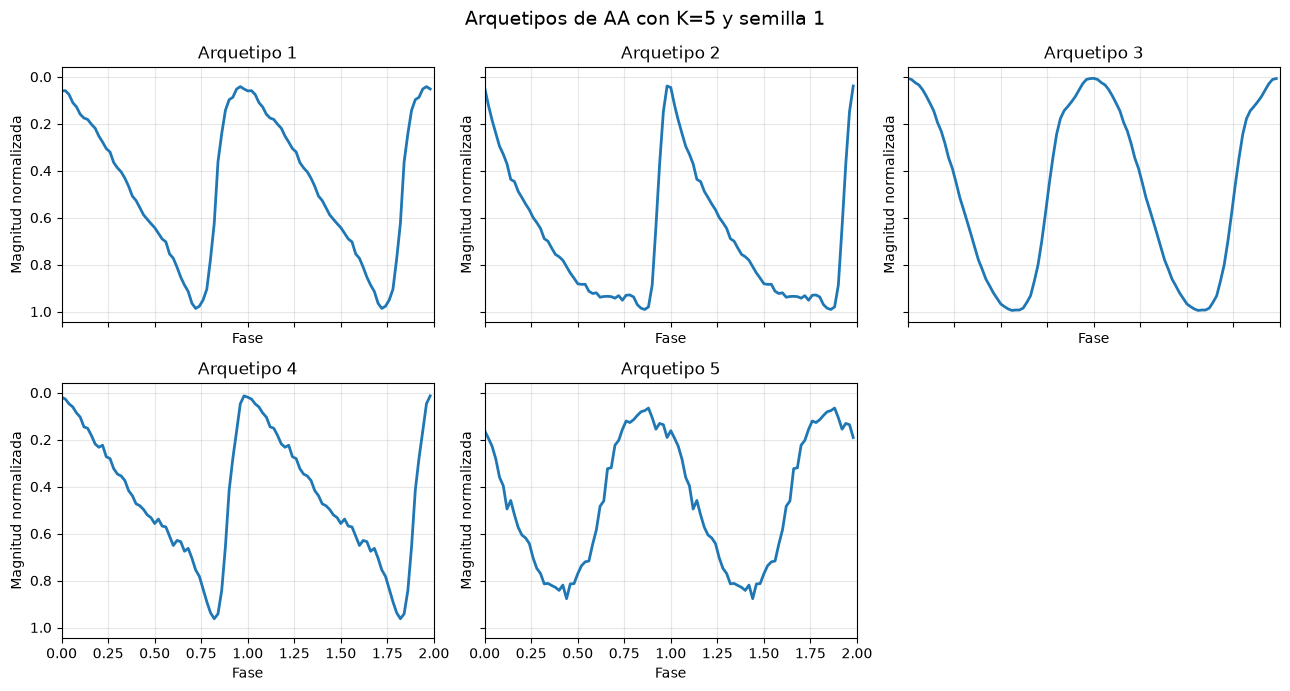

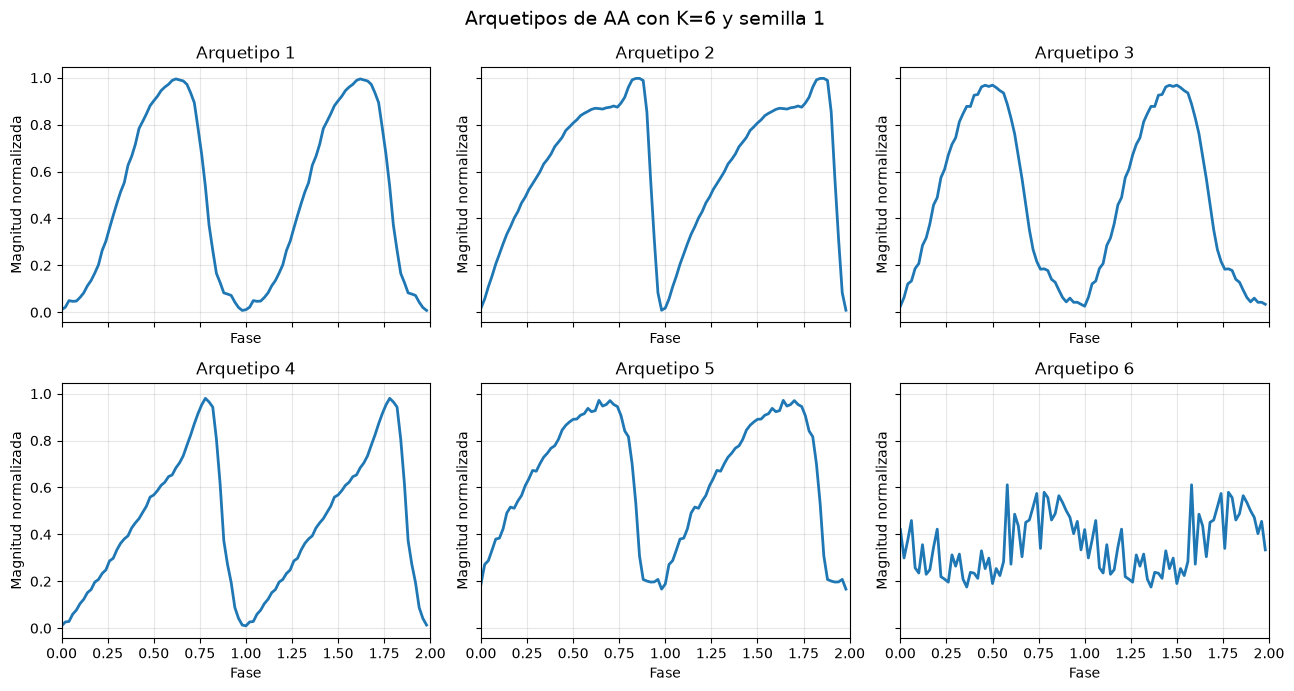

In [14]:
def cargar_arquetipos(
    k,
    seed=1,
):
    fila = (
        df_comparacion_k.loc[
            df_comparacion_k["K"].eq(k)
            & df_comparacion_k[
                "seed_modelo"
            ].eq(seed)
        ]
        .iloc[0]
    )

    carpeta_experimento = (
        PROJECT_ROOT
        / "resultados"
        / "experimentos"
        / str(fila["experiment_id"])
    )

    return np.load(
        carpeta_experimento
        / "patrones.npy"
    )


for k in (5, 6):
    arquetipos = cargar_arquetipos(
        k=k,
        seed=1,
    )

    fases = np.linspace(
        0,
        1,
        arquetipos.shape[1],
        endpoint=False,
    )

    fases_duplicadas = np.concatenate(
        [
            fases,
            fases + 1,
        ]
    )

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(13, 7),
        sharex=True,
        sharey=True,
    )

    for indice, ax in enumerate(
        axes.flat
    ):
        if indice < k:
            curva_duplicada = np.concatenate(
                [
                    arquetipos[indice],
                    arquetipos[indice],
                ]
            )

            ax.plot(
                fases_duplicadas,
                curva_duplicada,
                linewidth=2,
            )

            ax.set_title(
                f"Arquetipo {indice + 1}"
            )

            ax.set_xlabel("Fase")
            ax.set_ylabel(
                "Magnitud normalizada"
            )

            ax.set_xlim(
                0,
                2,
            )

            ax.invert_yaxis()
            ax.grid(alpha=0.3)
        else:
            ax.axis("off")

    fig.suptitle(
        f"Arquetipos de AA con K={k} "
        "y semilla 1",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()

,observacion_id,star_id_base,subtipo_rrlyrae,alpha_arquetipo_6,arquetipo_dominante
0,OGLEIII_OGLE-SMC-RRLYR-1609,OGLE-SMC-RRLYR-1609,RRc,0.877457,6
1,OGLEIII_OGLE-LMC-RRLYR-08281,OGLE-LMC-RRLYR-08281,RRab,0.787682,6
2,OGLEIII_OGLE-LMC-RRLYR-13719,OGLE-LMC-RRLYR-13719,RRc,0.542437,6
3,OGLEIV_OGLE-LMC-RRLYR-09216,OGLE-LMC-RRLYR-09216,RRc,0.526324,6
4,OGLEIII_OGLE-LMC-RRLYR-20317,OGLE-LMC-RRLYR-20317,RRab,0.505096,6
5,OGLEIV_OGLE-SMC-RRLYR-0366,OGLE-SMC-RRLYR-0366,RRc,0.495207,3
6,OGLEIII_OGLE-LMC-RRLYR-22786,OGLE-LMC-RRLYR-22786,RRab,0.480671,6
7,OGLEIII_OGLE-LMC-RRLYR-21209,OGLE-LMC-RRLYR-21209,RRc,0.479956,6
8,OGLEIII_OGLE-LMC-RRLYR-22742,OGLE-LMC-RRLYR-22742,RRab,0.465541,6
9,OGLEIII_OGLE-LMC-RRLYR-23988,OGLE-LMC-RRLYR-23988,RRd,0.451659,4


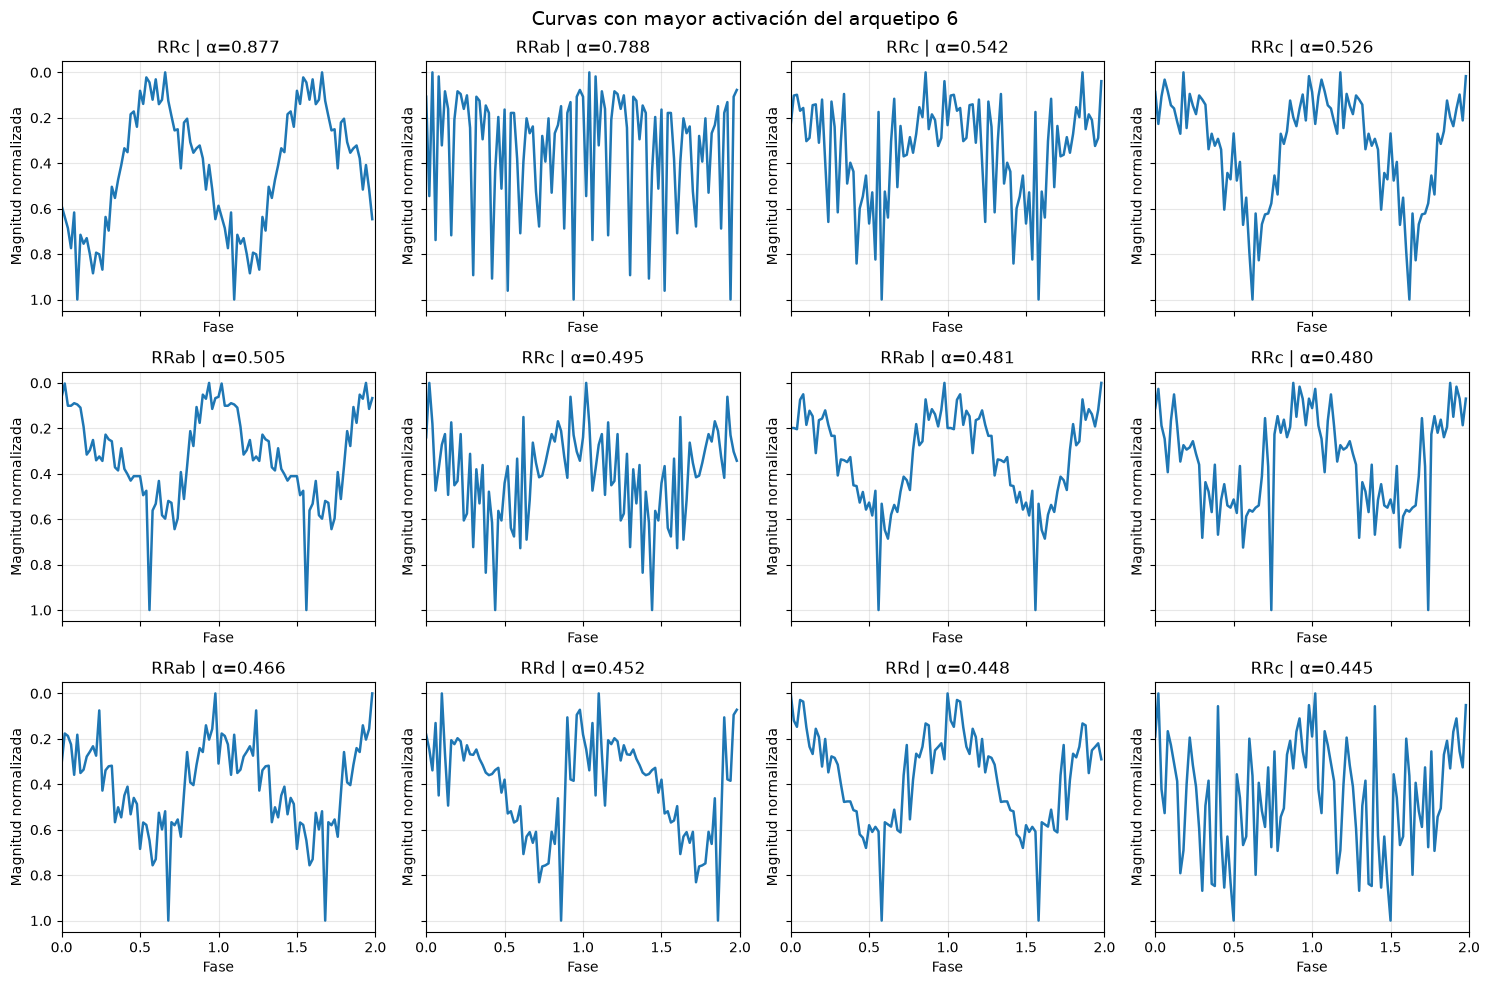

In [15]:
from experimento_aa import (
    prepare_aa_data,
)


fila_k6_seed1 = (
    df_comparacion_k.loc[
        df_comparacion_k["K"].eq(6)
        & df_comparacion_k[
            "seed_modelo"
        ].eq(1)
    ]
    .iloc[0]
)

carpeta_k6_seed1 = (
    PROJECT_ROOT
    / "resultados"
    / "experimentos"
    / str(
        fila_k6_seed1[
            "experiment_id"
        ]
    )
)

alphas_val_k6 = np.load(
    carpeta_k6_seed1
    / "alphas_val.npy"
)

ids_val_k6 = np.load(
    carpeta_k6_seed1
    / "ids_val.npy"
)

grupos_val_k6 = np.load(
    carpeta_k6_seed1
    / "grupos_val.npy"
)

(
    _,
    X_val_k6,
    _,
    metadata_val_k6,
) = prepare_aa_data(
    dataset="medianas_fase_50",
    normalizacion="minmax",
)

ids_metadata = (
    metadata_val_k6[
        "observacion_id"
    ]
    .astype(str)
    .to_numpy()
)

if not np.array_equal(
    ids_val_k6.astype(str),
    ids_metadata,
):
    raise ValueError(
        "Los identificadores guardados no "
        "coinciden con la matriz de validación."
    )


INDICE_ARQUETIPO_6 = 5
N_CURVAS_VISUALIZAR = 12

activaciones_arquetipo_6 = (
    alphas_val_k6[
        :,
        INDICE_ARQUETIPO_6,
    ]
)

indices_mayor_activacion = (
    np.argsort(
        activaciones_arquetipo_6
    )[-N_CURVAS_VISUALIZAR:]
    [::-1]
)

resumen_curvas = (
    metadata_val_k6.iloc[
        indices_mayor_activacion
    ][
        [
            "observacion_id",
            "star_id_base",
            "subtipo_rrlyrae",
        ]
    ]
    .copy()
)

resumen_curvas[
    "alpha_arquetipo_6"
] = activaciones_arquetipo_6[
    indices_mayor_activacion
]

resumen_curvas[
    "arquetipo_dominante"
] = (
    grupos_val_k6[
        indices_mayor_activacion
    ]
    + 1
)

display(
    resumen_curvas.reset_index(
        drop=True
    )
)


fases = np.linspace(
    0,
    1,
    X_val_k6.shape[1],
    endpoint=False,
)

fases_duplicadas = np.concatenate(
    [
        fases,
        fases + 1,
    ]
)

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(15, 10),
    sharex=True,
    sharey=True,
)

for posicion, indice_curva in enumerate(
    indices_mayor_activacion
):
    ax = axes.flat[posicion]

    curva_duplicada = np.concatenate(
        [
            X_val_k6[indice_curva],
            X_val_k6[indice_curva],
        ]
    )

    subtipo = metadata_val_k6.iloc[
        indice_curva
    ]["subtipo_rrlyrae"]

    alpha = activaciones_arquetipo_6[
        indice_curva
    ]

    ax.plot(
        fases_duplicadas,
        curva_duplicada,
        linewidth=1.8,
    )

    ax.set_title(
        f"{subtipo} | α={alpha:.3f}"
    )

    ax.set_xlim(0, 2)
    ax.set_xlabel("Fase")
    ax.set_ylabel(
        "Magnitud normalizada"
    )
    ax.grid(alpha=0.3)

axes.flat[0].invert_yaxis()

fig.suptitle(
    "Curvas con mayor activación "
    "del arquetipo 6",
    fontsize=14,
)

plt.tight_layout()
plt.show()